In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import optuna

# Set random seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select numerical columns for scaling (remove 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Prepare features and labels
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Reshape X to 2x4 grid based on the number of features
X = X.reshape(-1, 1, 2, 4)  # Reshape into a 2x4 grid (8 features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert data to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN-BiLSTM model
class CropCNNBiLSTM(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size, lstm_hidden_size, lstm_layers):
        super(CropCNNBiLSTM, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        # CNN layers
        for i in range(num_layers):
            in_channels = 1 if i == 0 else init_channels
            self.convs.append(
                nn.Conv2d(in_channels, init_channels, kernel_size=kernel_size, padding=1)
            )

        # Calculate the output size after passing through CNN layers
        self.conv_output_size = self._get_conv_output_size(input_shape)

        # LSTM layers
        self.lstm = nn.LSTM(input_size=self.conv_output_size, hidden_size=lstm_hidden_size,
                            num_layers=lstm_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(lstm_hidden_size * 2, num_classes)  # BiLSTM doubles the hidden size

    def _get_conv_output_size(self, input_shape):
        # Test a dummy input through the CNN layers to get the output size
        dummy_input = torch.zeros(1, *input_shape)
        x = dummy_input
        for conv in self.convs:
            x = F.relu(conv(x))
        return x.view(1, -1).size(1)  # Flatten and return the number of features

    def forward(self, x):
        for conv in self.convs:
            x = F.relu(conv(x))

        x = x.view(x.size(0), -1)  # Flatten before LSTM
        x = x.unsqueeze(1)  # Add an extra dimension to match LSTM input
        x, _ = self.lstm(x)
        x = x[:, -1, :]  # Take the last time-step for BiLSTM
        x = self.fc(x)
        return x


# Define Optuna objective function
def objective(trial):
    num_layers = trial.suggest_int('num_layers', 1, 3)
    init_channels = trial.suggest_categorical('init_channels', [16, 32, 64])
    kernel_size = trial.suggest_int('kernel_size', 2, 3)
    lstm_hidden_size = trial.suggest_int('lstm_hidden_size', 64, 256)
    lstm_layers = trial.suggest_int('lstm_layers', 1, 3)
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    epochs = trial.suggest_int('epochs', 10, 30)

    model = CropCNNBiLSTM(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                          num_layers=num_layers, init_channels=init_channels,
                          kernel_size=kernel_size, lstm_hidden_size=lstm_hidden_size,
                          lstm_layers=lstm_layers)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Validation Accuracy
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.tolist())
            all_targets.extend(y_batch.tolist())

    accuracy = accuracy_score(all_targets, all_predictions)
    return accuracy

# Run Optuna optimization
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Get the best parameters
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2025-01-18 16:57:01,359] A new study created in memory with name: no-name-04c5a8ef-fbe1-4456-8e23-1cae8d93c723
<ipython-input-2-0268c9106bc3>:98: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-01-18 16:57:43,235] Trial 0 finished with value: 0.9196969696969697 and parameters: {'num_layers': 2, 'init_channels': 16, 'kernel_size': 2, 'lstm_hidden_size': 94, 'lstm_layers': 1, 'lr': 0.005399484409787433, 'epochs': 22}. Best is trial 0 with value: 0.9196969696969697.
<ipython-input-2-0268c9106bc3>:98: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-01-18 16:58:42,0

Best hyperparameters: {'num_layers': 3, 'init_channels': 16, 'kernel_size': 2, 'lstm_hidden_size': 99, 'lstm_layers': 1, 'lr': 0.0008564468987587281, 'epochs': 23}


In [ ]:
best_params


{'num_layers': 3,
 'init_channels': 16,
 'kernel_size': 2,
 'lstm_hidden_size': 99,
 'lstm_layers': 1,
 'lr': 0.0008564468987587281,
 'epochs': 23}

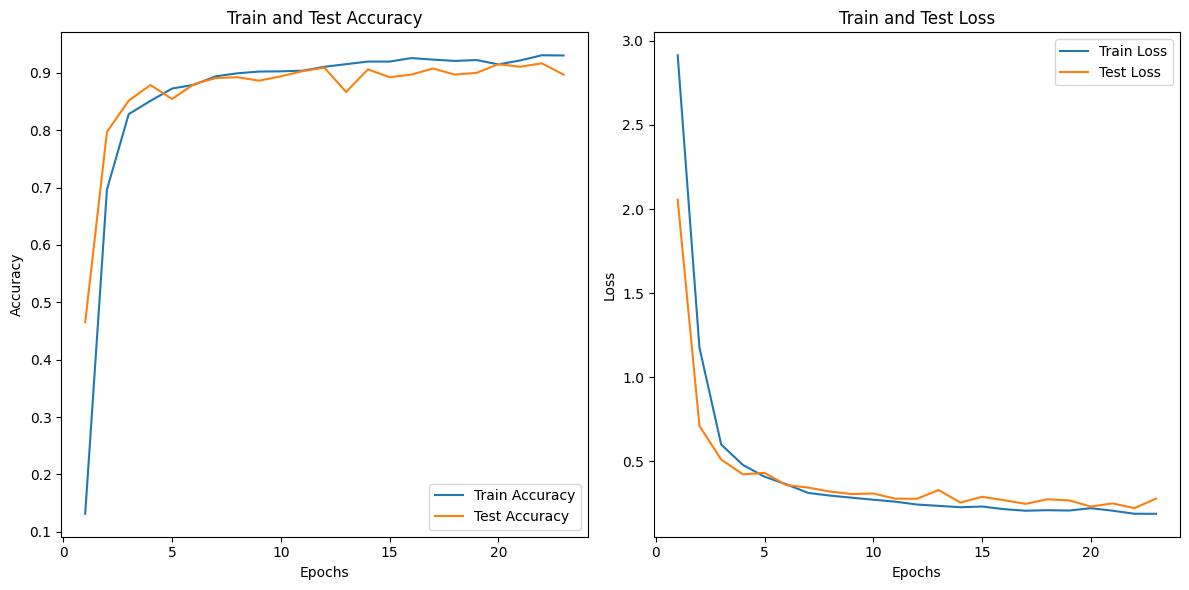

Epoch with Highest Test Accuracy: 22
Train Accuracy at Best Epoch: 0.9307
Test Accuracy at Best Epoch: 0.9167
Test Precision at Best Epoch: 0.4608
Test Recall at Best Epoch: 0.5588
Test F1-Score at Best Epoch: 0.4804


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
 import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.optim import Adam

# Assuming best_params and data loaders are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

model = CropCNNBiLSTM(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                      num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                      kernel_size=best_params['kernel_size'], lstm_hidden_size=best_params['lstm_hidden_size'],
                      lstm_layers=best_params['lstm_layers'])
optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Track metrics for plotting
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []
torch.manual_seed(seed)
np.random.seed(seed)

for epoch in range(best_params['epochs']):
    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)
torch.manual_seed(seed)
np.random.seed(seed)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnnbilstm.png',transparent=True)  # Save the plot as an image file

plt.show()

# Find the epoch with the highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Get the corresponding train and test accuracy for that epoch
best_train_accuracy = train_accuracies[best_epoch]
best_test_accuracy = test_accuracies[best_epoch]

# Get all the targets and predictions for the best epoch
best_all_targets = all_targets[best_epoch * len(test_loader): (best_epoch + 1) * len(test_loader)]
best_all_predictions = all_predictions[best_epoch * len(test_loader): (best_epoch + 1) * len(test_loader)]

# Calculate precision, recall, and F1-score
test_precision = precision_score(best_all_targets, best_all_predictions, average="macro")
test_recall = recall_score(best_all_targets, best_all_predictions, average="macro")
test_f1 = f1_score(best_all_targets, best_all_predictions, average="macro")

# Print the results
print(f"Epoch with Highest Test Accuracy: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best Epoch: {best_test_accuracy:.4f}")
print(f"Test Precision at Best Epoch: {test_precision:.4f}")
print(f"Test Recall at Best Epoch: {test_recall:.4f}")
print(f"Test F1-Score at Best Epoch: {test_f1:.4f}")


In [ ]:
from sklearn.metrics import classification_report

# After calculating y_true and y_pred during the validation phase, add this code
# Print classification report
print("\nClassification Report (Best Epoch):")
print(classification_report(all_targets,all_predictions))



Classification Report (Best Epoch):
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       690
           1       0.81      0.84      0.83       690
           2       0.68      0.69      0.69       690
           3       0.75      0.75      0.75       690
           4       0.98      0.97      0.98       690
           5       0.93      0.98      0.95       690
           6       0.90      0.90      0.90       690
           7       0.79      0.69      0.74       690
           8       0.85      0.87      0.86       690
           9       0.92      0.90      0.91       690
          10       0.81      0.85      0.83       690
          11       0.79      0.80      0.80       690
          12       0.98      0.99      0.98       690
          13       0.99      0.98      0.99       690
          14       0.72      0.74      0.73       690
          15       0.89      1.00      0.94       690
          16       0.90      0.87      0.89 

Epoch 1/23:
  Train Accuracy: 0.141, Train Loss: 2.929
  Test Accuracy: 0.405, Test Loss: 2.030
Epoch 2/23:
  Train Accuracy: 0.673, Train Loss: 1.187
  Test Accuracy: 0.798, Test Loss: 0.737
Epoch 3/23:
  Train Accuracy: 0.809, Train Loss: 0.638
  Test Accuracy: 0.841, Test Loss: 0.554
Epoch 4/23:
  Train Accuracy: 0.858, Train Loss: 0.482
  Test Accuracy: 0.865, Test Loss: 0.440
Epoch 5/23:
  Train Accuracy: 0.863, Train Loss: 0.428
  Test Accuracy: 0.862, Test Loss: 0.422
Epoch 6/23:
  Train Accuracy: 0.877, Train Loss: 0.384
  Test Accuracy: 0.888, Test Loss: 0.355
Epoch 7/23:
  Train Accuracy: 0.884, Train Loss: 0.346
  Test Accuracy: 0.876, Test Loss: 0.368
Epoch 8/23:
  Train Accuracy: 0.896, Train Loss: 0.316
  Test Accuracy: 0.891, Test Loss: 0.318
Epoch 9/23:
  Train Accuracy: 0.897, Train Loss: 0.302
  Test Accuracy: 0.902, Test Loss: 0.310
Epoch 10/23:
  Train Accuracy: 0.898, Train Loss: 0.280
  Test Accuracy: 0.905, Test Loss: 0.288
Epoch 11/23:
  Train Accuracy: 0.909, T

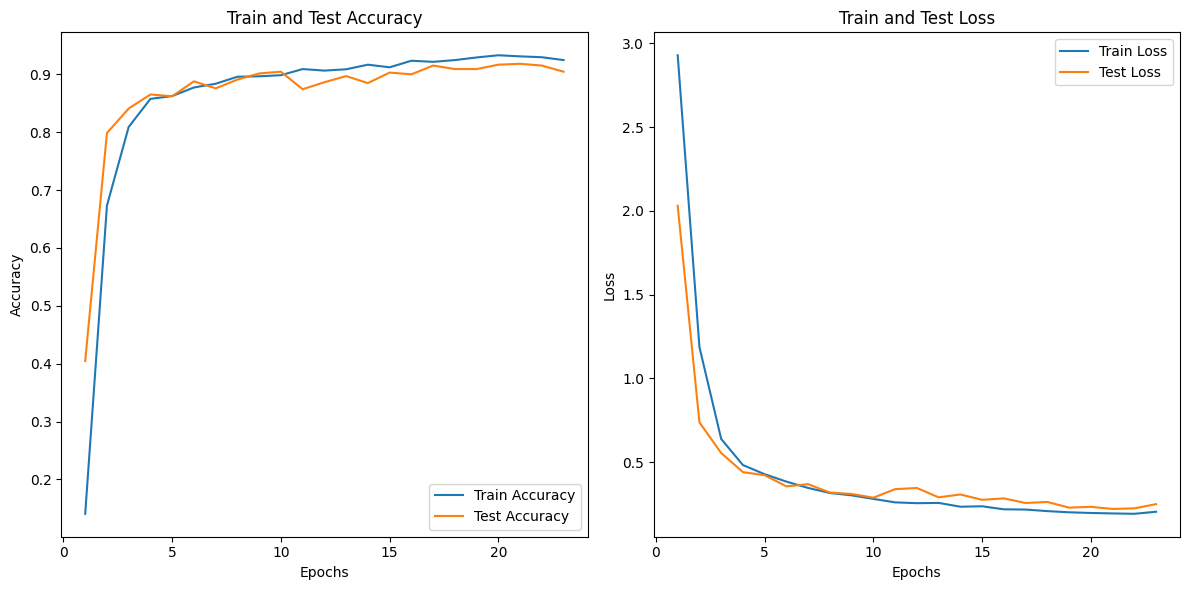


Classification Report:
                   precision    recall  f1-score   support

       Aman Rice      0.630     0.603     0.616       690
       Aush Rice      0.792     0.843     0.817       690
            Bean      0.698     0.658     0.678       690
       Boro Rice      0.723     0.690     0.706       690
        Calabash      0.980     0.977     0.978       690
     Cauliflower      0.965     0.948     0.956       690
Colocasia leaves      0.881     0.909     0.894       690
            Corn      0.841     0.635     0.723       690
        Eggplant      0.920     0.854     0.886       690
            Jute      0.926     0.886     0.905       690
       Leafy Veg      0.826     0.871     0.848       690
        Oil crop      0.769     0.867     0.815       690
           Onion      0.995     0.961     0.978       690
          Papaya      0.980     1.000     0.990       690
          Peanut      0.731     0.751     0.741       690
       Pineapple      0.947     1.000     0.97

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from torch.optim import Adam
import numpy as np

# Assuming best_params, CropCNNBiLSTM, train_loader, test_loader, and label_encoder are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

model = CropCNNBiLSTM(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                      num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                      kernel_size=best_params['kernel_size'], lstm_hidden_size=best_params['lstm_hidden_size'],
                      lstm_layers=best_params['lstm_layers'])
optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Track metrics for plotting and reporting
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []

for epoch in range(best_params['epochs']):
    # Training
    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    epoch_train_targets, epoch_train_predictions = [], []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()
        epoch_train_targets.extend(y_batch.tolist())
        epoch_train_predictions.extend(predicted.tolist())

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    epoch_test_targets, epoch_test_predictions = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            epoch_test_targets.extend(y_batch.tolist())
            epoch_test_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

    # Print metrics for this epoch
    print(f"Epoch {epoch + 1}/{best_params['epochs']}:")
    print(f"  Train Accuracy: {train_accuracy:.3f}, Train Loss: {train_losses[-1]:.3f}")
    print(f"  Test Accuracy: {test_accuracy:.3f}, Test Loss: {test_losses[-1]:.3f}")

    # Store all test targets and predictions for classification report
    all_targets.extend(epoch_test_targets)
    all_predictions.extend(epoch_test_predictions)

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnnbilstm.png', transparent=True)  # Save the plot as an image file

plt.show()

# Generate classification report for all test data
test_report = classification_report(all_targets, all_predictions, target_names=label_encoder.classes_, digits=3)
print("\nClassification Report:\n", test_report)


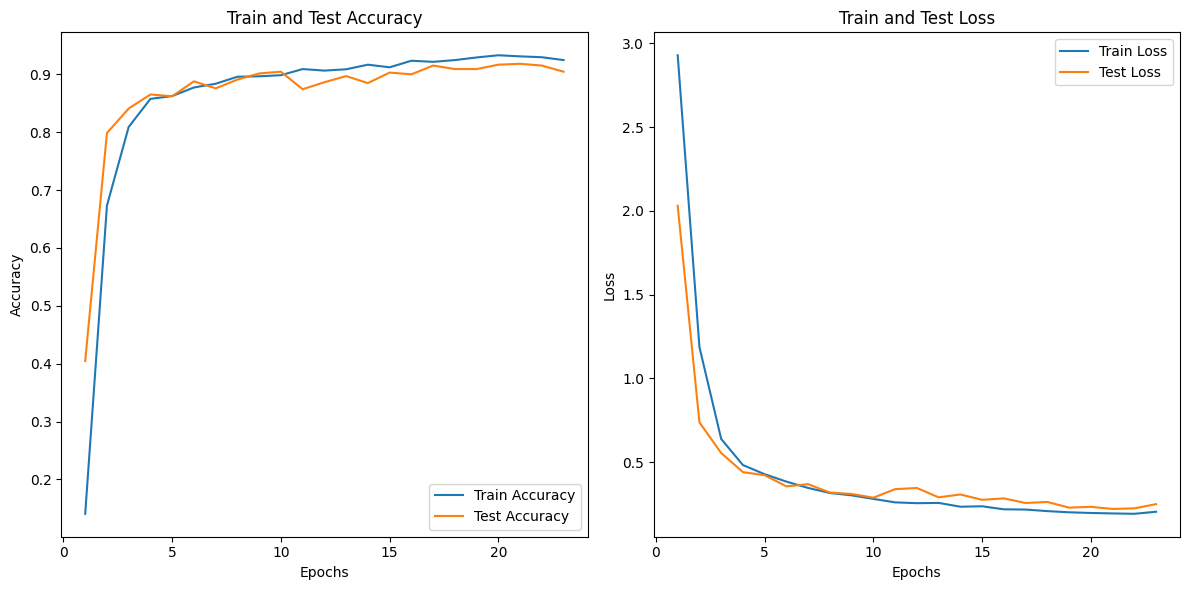

Epoch with Highest Test Accuracy: 21
Train Accuracy at Best Epoch: 0.9311
Test Accuracy at Best Epoch: 0.9182
Test Precision: 0.8686
Test Recall: 0.8681
Test F1-Score: 0.8669
Average Training Time per Epoch: 1.54 seconds
Model Size: 2.12 MB
Number of Parameters: 530050


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.optim import Adam
import time

# Assuming best_params and data loaders are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

model = CropCNNBiLSTM(
    input_shape=(1, 2, 4),
    num_classes=len(label_encoder.classes_),
    num_layers=best_params['num_layers'],
    init_channels=best_params['init_channels'],
    kernel_size=best_params['kernel_size'],
    lstm_hidden_size=best_params['lstm_hidden_size'],
    lstm_layers=best_params['lstm_layers']
)
optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Calculate the number of parameters and model size
num_parameters = sum(p.numel() for p in model.parameters())
model_size = sum(p.element_size() * p.numel() for p in model.parameters()) / 1e6  # Convert to MB

# Track metrics for plotting and timing
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []
epoch_times = []

for epoch in range(best_params['epochs']):
    start_time = time.time()  # Start timing the epoch

    # Training phase
    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation phase
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

    end_time = time.time()  # End timing the epoch
    epoch_times.append(end_time - start_time)

# Calculate average training time per epoch
avg_epoch_time = sum(epoch_times) / len(epoch_times)

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnnbilstm.png', transparent=True)  # Save the plot as an image file
plt.show()

# Find the epoch with the highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Get the corresponding train and test accuracy for that epoch
best_train_accuracy = train_accuracies[best_epoch]
best_test_accuracy = test_accuracies[best_epoch]

# Calculate precision, recall, and F1-score
test_precision = precision_score(all_targets, all_predictions, average="macro")
test_recall = recall_score(all_targets, all_predictions, average="macro")
test_f1 = f1_score(all_targets, all_predictions, average="macro")

# Print the results
print(f"Epoch with Highest Test Accuracy: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best Epoch: {best_test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Average Training Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Model Size: {model_size:.2f} MB")
print(f"Number of Parameters: {num_parameters}")
